# 🎬 Streaming Platform – Downgrade Prediction Pipeline
**Divisi Python Machine Learning – Vinix7 (PT. VINIX SEVEN AURUM)**

---

**Tujuan:** Membangun pipeline ML yang bersih dan siap deploy untuk memprediksi apakah pengguna Premium berisiko melakukan downgrade langganan bulan depan.

| Info | Detail |
|------|--------|
| Dataset | `streaming_platform_dataset.csv` |
| Target | `subscription_action` → binary: **Downgrade** vs **Non-Downgrade** |
| Framework | Scikit-learn Pipeline + ColumnTransformer |
| Export | `joblib` dengan versioning standar |

## 📦 Task 0 – Import Libraries & Reproducibility Setup

In [386]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import os
from datetime import datetime

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Scikit-learn: Pipeline & Transformers ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

# ── Scikit-learn: Model & Evaluation ─────────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from scipy.stats import randint, uniform
from sklearn.calibration import CalibratedClassifierCV
import shap

# ── Export ────────────────────────────────────────────────────────────────────
import joblib

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
RANDOM_STATE = 42          # Wajib untuk reproducibility
np.random.seed(RANDOM_STATE)

print("✅ Semua library berhasil diimport.")
print(f"📅 Tanggal eksekusi: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Semua library berhasil diimport.
📅 Tanggal eksekusi: 2026-05-16 20:33:38


## 🔍 Task 0.1 – Load & Exploratory Data Analysis (EDA)

In [387]:
# Load dataset
df = pd.read_csv('streaming_platform_dataset.csv')

print(f"📊 Shape dataset: {df.shape}")
print(f"\n📋 Kolom: {df.columns.tolist()}")
df.head()

📊 Shape dataset: (4000, 7)

📋 Kolom: ['user_id', 'tenure_months', 'monthly_watch_hours', 'customer_support_calls', 'device_type', 'payment_method', 'subscription_action']


,user_id,tenure_months,monthly_watch_hours,customer_support_calls,device_type,payment_method,subscription_action
0,USR-00001,39,47.0,3,Smart TV,E-Wallet,Retain
1,USR-00002,52,98.7,5,Mobile,Credit Card,Retain
2,USR-00003,29,140.9,3,Mobile,Credit Card,Retain
3,USR-00004,15,130.9,5,Mobile,Credit Card,Retain
4,USR-00005,43,115.4,0,Web,Bank Transfer,Retain


In [388]:
# Info & tipe data
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df.info()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 4000 non-null   str    
 1   tenure_months           4000 non-null   int64  
 2   monthly_watch_hours     4000 non-null   float64
 3   customer_support_calls  4000 non-null   int64  
 4   device_type             4000 non-null   str    
 5   payment_method          4000 non-null   str    
 6   subscription_action     4000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 218.9 KB


In [389]:
# Statistik deskriptif
df.describe(include='all')

,user_id,tenure_months,monthly_watch_hours,customer_support_calls,device_type,payment_method,subscription_action
count,4000,4000.000000,4000.000000,4000.000000,4000,4000,4000
unique,4000,NaN,NaN,NaN,3,3,4
top,USR-00001,NaN,NaN,NaN,Mobile,Credit Card,Retain
freq,1,NaN,NaN,NaN,1604,1990,3250
mean,NaN,30.022750,75.223375,2.464750,NaN,NaN,NaN
std,NaN,16.942919,42.669184,1.710114,NaN,NaN,NaN
min,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN
25%,NaN,15.000000,38.600000,1.000000,NaN,NaN,NaN
50%,NaN,30.000000,74.500000,2.000000,NaN,NaN,NaN
75%,NaN,45.000000,111.800000,4.000000,NaN,NaN,NaN


In [390]:
# Cek missing values
missing = df.isnull().sum()
print("Missing values per kolom:")
print(missing[missing >= 0].to_string())

Missing values per kolom:
user_id                   0
tenure_months             0
monthly_watch_hours       0
customer_support_calls    0
device_type               0
payment_method            0
subscription_action       0


Distribusi Kelas Target:
  Retain      :  3250 (81.2%)
  Upgrade     :   435 (10.9%)
  Downgrade   :   206 (5.1%)
  Churn       :   109 (2.7%)


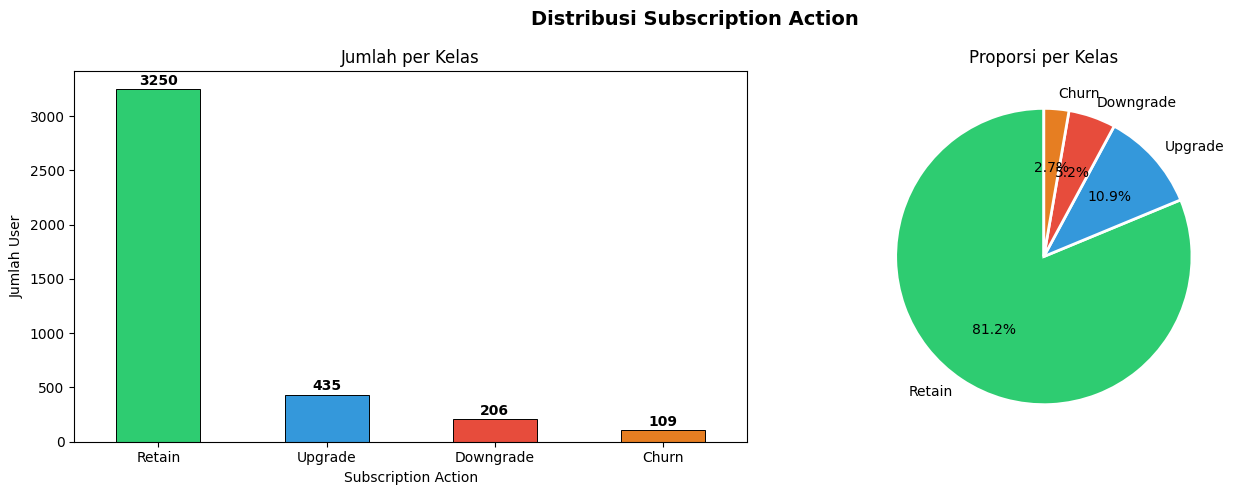


⚠️  INSIGHT: Dataset sangat imbalanced! 'Downgrade' hanya ~5.15%
    → Accuracy tinggi TIDAK berarti model bagus (accuracy paradox).
    → Fokus ke Recall & F1-Score untuk kelas 'Downgrade'.


In [391]:
# Distribusi target – ini krusial untuk memahami class imbalance!
target_counts = df['subscription_action'].value_counts()
target_pct = df['subscription_action'].value_counts(normalize=True) * 100

print("Distribusi Kelas Target:")
print("=" * 40)
for cls in target_counts.index:
    print(f"  {cls:<12}: {target_counts[cls]:>5} ({target_pct[cls]:.1f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Subscription Action', fontsize=14, fontweight='bold')

# Bar plot
colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Jumlah per Kelas')
axes[0].set_xlabel('Subscription Action')
axes[0].set_ylabel('Jumlah User')
axes[0].tick_params(axis='x', rotation=0)
for bar, count in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi per Kelas')

plt.tight_layout()
plt.show()

print("\n⚠️  INSIGHT: Dataset sangat imbalanced! 'Downgrade' hanya ~5.15%")
print("    → Accuracy tinggi TIDAK berarti model bagus (accuracy paradox).")
print("    → Fokus ke Recall & F1-Score untuk kelas 'Downgrade'.")

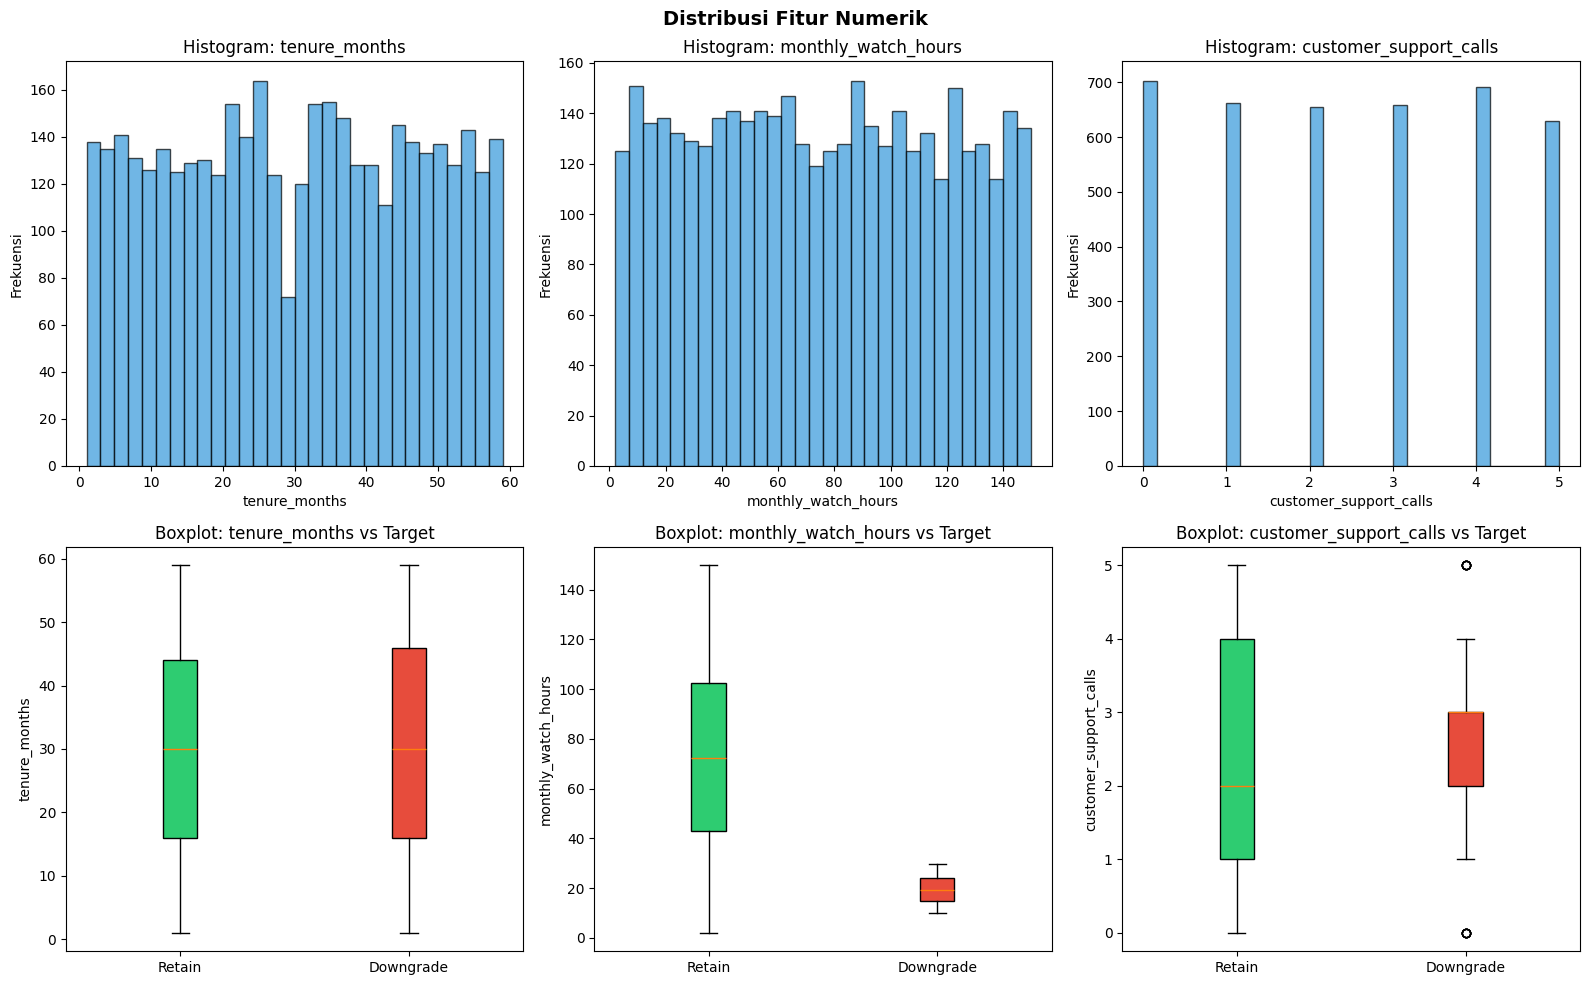

In [392]:
# EDA fitur numerik
numerical_cols = ['tenure_months', 'monthly_watch_hours', 'customer_support_calls']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=30, edgecolor='black', color='#3498db', alpha=0.7)
    axes[0, i].set_title(f'Histogram: {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot by target
    df_plot = df[df['subscription_action'].isin(['Retain', 'Downgrade'])]
    groups = [df_plot[df_plot['subscription_action'] == a][col].values
              for a in ['Retain', 'Downgrade']]
    bp = axes[1, i].boxplot(groups, labels=['Retain', 'Downgrade'],
                             patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1, i].set_title(f'Boxplot: {col} vs Target')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

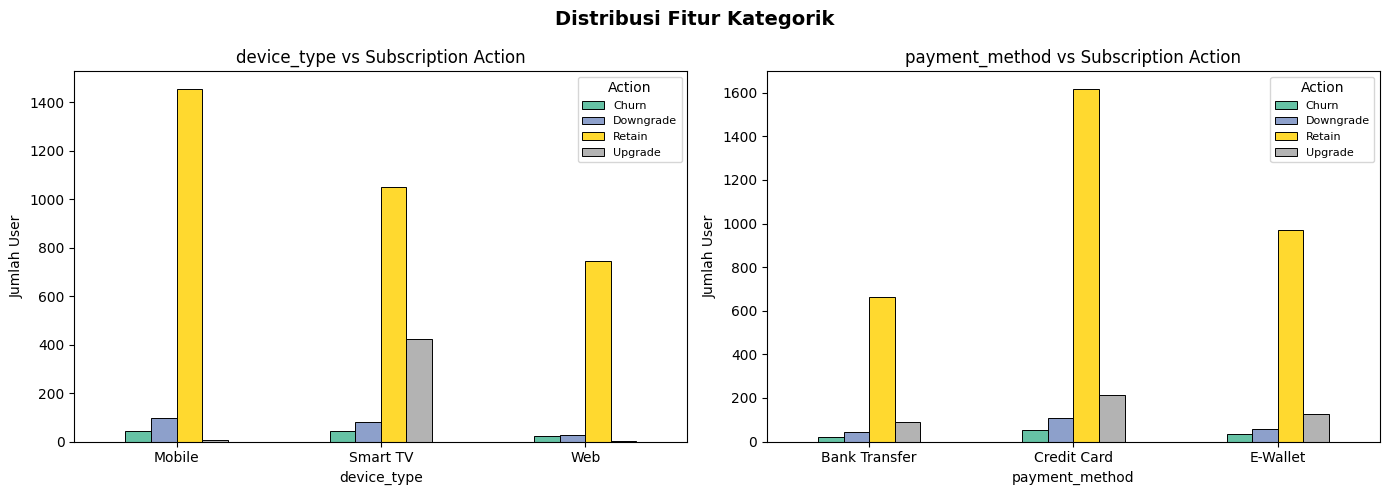

In [393]:
# EDA fitur kategorik
cat_cols = ['device_type', 'payment_method']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Fitur Kategorik', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['subscription_action'])
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black', linewidth=0.7)
    axes[i].set_title(f'{col} vs Subscription Action')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah User')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Action', fontsize=8)

plt.tight_layout()
plt.show()

## 🔧 Task 0.2 – Binarisasi Target Variable

Karena tujuan proyek adalah mendeteksi **risiko downgrade**, kita binarisasi target:
- `1` → **Downgrade** (kelas positif / yang ingin kita deteksi)
- `0` → **Non-Downgrade** (Retain, Upgrade, Churn digabung sebagai "bukan downgrade")

> **Kenapa begini?** Ini adalah keputusan bisnis. Model difokuskan untuk menjawab satu pertanyaan spesifik: *"Apakah user ini akan downgrade?"* – bukan klasifikasi multi-kelas penuh.

In [394]:
df['watch_hours_per_month'] = (
    df['monthly_watch_hours'] / (df['tenure_months'] + 1)
)

df['support_calls_ratio'] = (
    df['customer_support_calls'] / (df['tenure_months'] + 1)
)

In [395]:
# Binarisasi target
df['target'] = (df['subscription_action'] == 'Downgrade').astype(int)

print("Distribusi target binary:")
print(df['target'].value_counts())
print()
print(f"Proporsi Downgrade: {df['target'].mean()*100:.2f}%")
print(f"Proporsi Non-Downgrade: {(1 - df['target'].mean())*100:.2f}%")

Distribusi target binary:
target
0    3794
1     206
Name: count, dtype: int64

Proporsi Downgrade: 5.15%
Proporsi Non-Downgrade: 94.85%


## ✂️ Task 0.3 – Train-Test Split (Stratified)

In [396]:
# Definisikan fitur
FEATURE_COLS = ['tenure_months', 'monthly_watch_hours',
                'customer_support_calls', 'device_type', 'payment_method', 'watch_hours_per_month', 'support_calls_ratio']
TARGET_COL = 'target'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Stratified split – penting agar proporsi kelas terjaga di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # ← Krusial untuk imbalanced data!
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nProposi Downgrade di train : {y_train.mean()*100:.2f}%")
print(f"Proporsi Downgrade di test  : {y_test.mean()*100:.2f}%")
print("\n✅ Stratified split berhasil – proporsi kelas terjaga.")

Training set  : 3200 samples
Test set      : 800 samples

Proposi Downgrade di train : 5.16%
Proporsi Downgrade di test  : 5.12%

✅ Stratified split berhasil – proporsi kelas terjaga.


## 🏗️ Task 1 – Build Pipeline (Clean Code Architecture)

Arsitektur pipeline menggunakan **ColumnTransformer** untuk memisahkan preprocessing numerik dan kategorik, lalu digabung dengan model dalam satu **Pipeline** scikit-learn.

```
X_raw
  │
  ├─► Numerical Branch: SimpleImputer(median) → StandardScaler
  │
  └─► Categorical Branch: SimpleImputer(most_frequent) → OneHotEncoder
         │
         └──────────────────── ColumnTransformer ──────────────────────
                                       │
                                 RandomForestClassifier
                                       │
                                  y_pred / proba
```

In [397]:
# ── Definisikan Kolom Berdasarkan Tipe Data ──────────────────────────────────
numerical_features = [
    'tenure_months',
    'monthly_watch_hours',
    'customer_support_calls',
    'watch_hours_per_month',
    'support_calls_ratio'
]

categorical_features = ['device_type','payment_method']

# ── Numerical Preprocessing Pipeline ─────────────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Categorical Preprocessing Pipeline ───────────────────────────────────────
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# ── ColumnTransformer ────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

# ── Full Pipeline: Preprocessor + HistGradientBoosting ──────────────────────
main_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=100
    ))
])

print(" HistGradientBoosting Pipeline berhasil dikonfigurasi!")

 HistGradientBoosting Pipeline berhasil dikonfigurasi!


In [398]:
# ── Hitung sample weight untuk imbalance ────────────────────────────────────
sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# ── Training model ─────────────────────────────────────────────────────────
main_pipeline.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weight
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 📊 Task 2 – Evaluasi Model

Ingat: **Accuracy bisa berbohong!** Karena hanya 5.15% user yang downgrade, model yang selalu prediksi "Non-Downgrade" akan dapat Accuracy ~94.85% – tapi sama sekali tidak berguna untuk bisnis.

In [399]:
y_pred = main_pipeline.predict(X_test)
y_proba = main_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy      : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report Baseline:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Downgrade (0)", "Downgrade (1)"]
))

Accuracy      : 97.75%
ROC-AUC Score : 0.9904

Classification Report Baseline:
                   precision    recall  f1-score   support

Non-Downgrade (0)       1.00      0.98      0.99       759
    Downgrade (1)       0.72      0.93      0.81        41

         accuracy                           0.98       800
        macro avg       0.86      0.95      0.90       800
     weighted avg       0.98      0.98      0.98       800



Hyperparameter Tuning dengan RandomizedSearchCV

In [400]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

param_dist = {
    "classifier__learning_rate": uniform(0.02, 0.08),
    "classifier__max_iter": randint(100, 400),
    "classifier__max_depth": randint(3, 8),
    "classifier__max_leaf_nodes": randint(15, 50),
    "classifier__min_samples_leaf": randint(10, 40),
    "classifier__l2_regularization": uniform(0.0, 1.0)
}

random_search = RandomizedSearchCV(
    estimator=main_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring="recall",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train,y_train,classifier__sample_weight=sample_weight)
best_pipeline = random_search.best_estimator_

print("="*60)
print("BEST TUNING RESULT")
print("="*60)
print(f"Best CV Recall Downgrade : {random_search.best_score_:.4f}")
print("\nBest Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
BEST TUNING RESULT
Best CV Recall Downgrade : 0.9576

Best Parameters:
{'classifier__l2_regularization': np.float64(0.4951769101112702), 'classifier__learning_rate': np.float64(0.02275108168921747), 'classifier__max_depth': 3, 'classifier__max_iter': 149, 'classifier__max_leaf_nodes': 18, 'classifier__min_samples_leaf': 11}


Kalibrasi dengan CalibratedClassifierCV

In [401]:
# ============================================================
# CALIBRATED CLASSIFIER CV
# ============================================================

calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",   # aman untuk dataset kecil
    cv=5
)

calibrated_pipeline.fit(X_train, y_train)

# Prediksi probabilitas calibrated
y_proba = calibrated_pipeline.predict_proba(X_test)[:, 1]

Auto Treshold

In [402]:
# ============================================================
# AUTO THRESHOLD - PRECISION MINIMAL 0.90
# ============================================================

min_precision = 0.95
thresholds = np.arange(0.01, 1.00, 0.01)

best_threshold = None
best_recall = -1

for threshold in thresholds:
    y_pred_temp = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, zero_division=0)

    if precision >= min_precision and recall > best_recall:
        best_threshold = threshold
        best_recall = recall

final_threshold = best_threshold

print("=" * 60)
print("FINAL SELECTED THRESHOLD")
print("=" * 60)
print(f"Final Precision Constraint : {min_precision}")
print(f"Final Threshold            : {final_threshold:.2f}")

FINAL SELECTED THRESHOLD
Final Precision Constraint : 0.95
Final Threshold            : 0.32


5 Fold Cross Validation

In [403]:
# CV dengan metrik recall untuk kelas Downgrade
cv_recall = cross_val_score(
    calibrated_pipeline, X, y,
    cv=cv,
    scoring='recall',      # recall untuk kelas positif (Downgrade)
    n_jobs=-1
)
cv_roc = cross_val_score(
    calibrated_pipeline, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("=" * 50)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)
print(f"Recall (Downgrade)  : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"ROC-AUC             : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print()
print("📌 Recall per fold:", [f"{v:.3f}" for v in cv_recall])

5-FOLD CROSS-VALIDATION RESULTS
Recall (Downgrade)  : 0.8740 ± 0.0788
ROC-AUC             : 0.9929 ± 0.0044

📌 Recall per fold: ['0.927', '0.780', '0.829', '1.000', '0.833']


In [404]:
# ============================================================
# FINAL EVALUATION - CALIBRATED MODEL
# ============================================================
y_pred_final = (y_proba >= final_threshold).astype(int)

print("=" * 60)
print("FINAL MODEL EVALUATION - CALIBRATED + AUTO THRESHOLD")
print("=" * 60)

print(f"Accuracy      : {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Non-Downgrade (0)", "Downgrade (1)"]
))

FINAL MODEL EVALUATION - CALIBRATED + AUTO THRESHOLD
Accuracy      : 99.38%
ROC-AUC Score : 0.9935

Classification Report:
                   precision    recall  f1-score   support

Non-Downgrade (0)       1.00      1.00      1.00       759
    Downgrade (1)       0.95      0.93      0.94        41

         accuracy                           0.99       800
        macro avg       0.97      0.96      0.97       800
     weighted avg       0.99      0.99      0.99       800



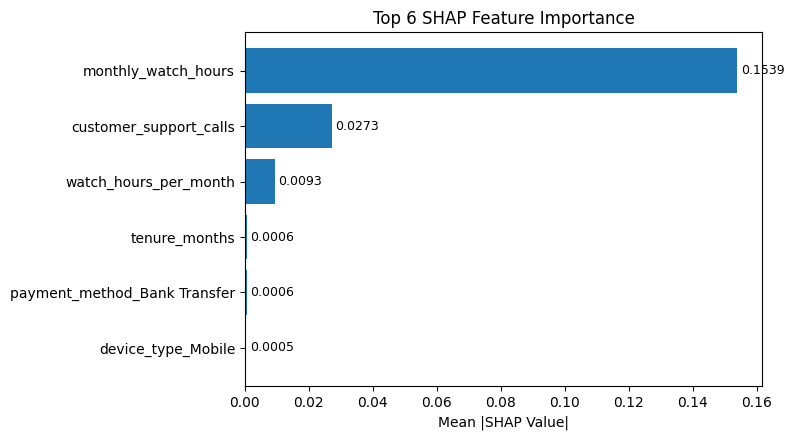

In [405]:
# Ambil model dan preprocessor
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["classifier"]

# Transform X_test
X_test_transformed = preprocessor.transform(X_test)

# Nama fitur setelah OneHotEncoder
cat_names = preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

feature_names = numerical_features + list(cat_names)

X_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Hitung SHAP
explainer = shap.PermutationExplainer(model.predict_proba, X_shap)
shap_values = explainer(X_shap.iloc[:100])

# Tabel importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_values[:, :, 1].values).mean(axis=0)
})

# Ambil Top 6 fitur
importance = (
    importance
    .sort_values("Importance", ascending=False)
    .head(6)
    .sort_values("Importance", ascending=True)
)

# Plot
plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    importance["Feature"],
    importance["Importance"]
)

# Tambahkan nilai di ujung bar
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va='center',
        fontsize=9
    )

plt.title("Top 6 SHAP Feature Importance")
plt.xlabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()

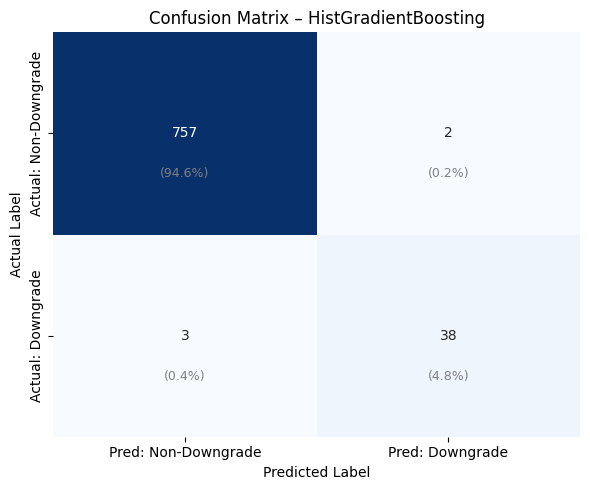

INTERPRETASI BISNIS – CONFUSION MATRIX
True Positive  (Downgrade diprediksi Downgrade) : 38
True Negative  (Retain diprediksi Retain)       : 757
False Positive (Retain diprediksi Downgrade)    : 2
False Negative (Downgrade diprediksi Retain)    : 3

Recall Downgrade    : 0.9268 (92.7%)
Precision Downgrade : 0.9500 (95.0%)


In [406]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred: Non-Downgrade', 'Pred: Downgrade'],
    yticklabels=['Actual: Non-Downgrade', 'Actual: Downgrade']
)

plt.title('Confusion Matrix – HistGradientBoosting')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Tambahkan interpretasi persentase
total = cm.sum()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        percentage = cm[i, j] / total * 100

        plt.text(
            j + 0.5,
            i + 0.7,
            f'({percentage:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            color='gray'
        )

plt.tight_layout()
plt.show()

# ============================================================
# BUSINESS INTERPRETATION
# ============================================================

recall_downgrade = tp / (tp + fn)
precision_downgrade = tp / (tp + fp)

print("=" * 60)
print("INTERPRETASI BISNIS – CONFUSION MATRIX")
print("=" * 60)

print(f"True Positive  (Downgrade diprediksi Downgrade) : {tp}")
print(f"True Negative  (Retain diprediksi Retain)       : {tn}")
print(f"False Positive (Retain diprediksi Downgrade)    : {fp}")
print(f"False Negative (Downgrade diprediksi Retain)    : {fn}")

print()
print(f"Recall Downgrade    : {recall_downgrade:.4f} ({recall_downgrade*100:.1f}%)")
print(f"Precision Downgrade : {precision_downgrade:.4f} ({precision_downgrade*100:.1f}%)")

## 💾 Task 3 – Versioning & Export Model

Format penamaan: `nama_model_v{versi}_{tanggal}.pkl`

In [407]:
# ── Standar Penamaan Versioning Profesional ───────────────────────────────────
MODEL_NAME = 'streaming_histgb_pipeline'
MODEL_VERSION = 'v1'
TODAY = datetime.now().strftime('%Y%m%d')

FILENAME = f"{MODEL_NAME}_{MODEL_VERSION}_{TODAY}.pkl"

print(f"📦 Nama file model: {FILENAME}")
print(f"📁 Lokasi export   : ./{FILENAME}")

📦 Nama file model: streaming_histgb_pipeline_v1_20260516.pkl
📁 Lokasi export   : ./streaming_histgb_pipeline_v1_20260516.pkl


In [408]:
# Export pipeline menggunakan joblib
# Joblib lebih efisien dari pickle untuk objek numpy/sklearn yang besar
joblib.dump(calibrated_pipeline, FILENAME)

# Verifikasi file berhasil dibuat
file_size = os.path.getsize(FILENAME)
file_size_kb = file_size / 1024

print("=" * 50)
print("✅ MODEL BERHASIL DIEKSPOR!")
print("=" * 50)
print(f"  Nama file  : {FILENAME}")
print(f"  Ukuran     : {file_size_kb:.2f} KB ({file_size:,} bytes)")
print(f"  Waktu ekspor: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ MODEL BERHASIL DIEKSPOR!
  Nama file  : streaming_histgb_pipeline_v1_20260516.pkl
  Ukuran     : 686.24 KB (702,707 bytes)
  Waktu ekspor: 2026-05-16 20:33:59


In [409]:
loaded_pipeline = joblib.load(FILENAME)

test_proba = loaded_pipeline.predict_proba(X_test[:5])[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

print("=" * 50)
print("✅ VERIFIKASI LOAD MODEL")
print("=" * 50)

for i, (pred, proba) in enumerate(zip(test_pred, test_proba)):
    label = "⚠️ DOWNGRADE" if pred == 1 else "✅ Non-Downgrade"
    print(f"User {i+1}: {label} | Probabilitas Downgrade: {proba:.4f}")

print("\n✅ Model loaded dan berfungsi normal.")

✅ VERIFIKASI LOAD MODEL
User 1: ✅ Non-Downgrade | Probabilitas Downgrade: 0.0007
User 2: ✅ Non-Downgrade | Probabilitas Downgrade: 0.0008
User 3: ⚠️ DOWNGRADE | Probabilitas Downgrade: 0.8157
User 4: ✅ Non-Downgrade | Probabilitas Downgrade: 0.0913
User 5: ✅ Non-Downgrade | Probabilitas Downgrade: 0.0008

✅ Model loaded dan berfungsi normal.


## 📝 Task 4 – MLOps Business Report

In [410]:
# ── Simulasi: Bagaimana cara load model dan pakai untuk prediksi baru ─────────

def predict_downgrade_risk(
    user_data: dict,
    model_path: str = FILENAME,
    threshold: float = final_threshold
) -> dict:

    pipeline = joblib.load(model_path)
    df_input = pd.DataFrame([user_data])

    df_input["watch_hours_per_month"] = (
        df_input["monthly_watch_hours"] / (df_input["tenure_months"] + 1)
    )

    df_input["support_calls_ratio"] = (
        df_input["customer_support_calls"] / (df_input["tenure_months"] + 1)
    )

    probability = pipeline.predict_proba(df_input)[0][1]
    prediction = 1 if probability >= threshold else 0

    risk_level = (
        "HIGH" if probability >= threshold else
        "MEDIUM" if probability >= threshold * 0.5 else
        "LOW"
    )

    return {
        "prediction": "DOWNGRADE" if prediction == 1 else "Non-Downgrade",
        "downgrade_probability": round(float(probability), 4),
        "risk_level": risk_level,
        "threshold_used": round(float(threshold), 4),
        "model_version": FILENAME
    }


# Test dengan user simulasi
sample_user = {
    "tenure_months": 36,
    "monthly_watch_hours": 15.0,
    "customer_support_calls": 2,
    "device_type": "Mobile",
    "payment_method": "E-Wallet"
}
    
result = predict_downgrade_risk(sample_user)
print("=" * 55)
print("CONTOH DEPLOYMENT – PREDIKSI SINGLE USER")
print("=" * 55)
print(f"  Input data    : tenure=36 bulan, watch=15 jam, support_calls=2, device=Mobile, payment=E-Wallet")
print(f"  Device        : Mobile | Payment: E-Wallet")
print(f"  Prediksi      : {result['prediction']}")
print(f"  Probabilitas  : {result['downgrade_probability']*100:.2f}%")
print(f"  Risk Level    : {result['risk_level']}")
print(f"  Model version : {result['model_version']}")

CONTOH DEPLOYMENT – PREDIKSI SINGLE USER
  Input data    : tenure=36 bulan, watch=15 jam, support_calls=2, device=Mobile, payment=E-Wallet
  Device        : Mobile | Payment: E-Wallet
  Prediksi      : DOWNGRADE
  Probabilitas  : 91.93%
  Risk Level    : HIGH
  Model version : streaming_histgb_pipeline_v1_20260516.pkl


In [411]:
print("=" * 65)
print("RINGKASAN AKHIR – STREAMING DOWNGRADE PREDICTION PIPELINE")
print("=" * 65)
print("✅ Model       : Calibrated Tuned HistGradientBoostingClassifier")
print("✅ Pipeline    : ColumnTransformer + sklearn Pipeline + CalibratedClassifierCV")
print(f"✅ Versioning  : {FILENAME}")
print(f"✅ Ukuran file : {os.path.getsize(FILENAME)/1024:.2f} KB")

print("\nMetrik Kunci (Test Set):")
print(f"Recall (Downgrade)    : {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision (Downgrade) : {precision_score(y_test, y_pred_final):.4f}")
print(f"F1-Score (Downgrade)  : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC Score         : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy              : {accuracy_score(y_test, y_pred_final):.4f}")

print("\n✅ Model siap untuk deployment ke sistem pemantauan pengguna.")
print("=" * 65)

RINGKASAN AKHIR – STREAMING DOWNGRADE PREDICTION PIPELINE
✅ Model       : Calibrated Tuned HistGradientBoostingClassifier
✅ Pipeline    : ColumnTransformer + sklearn Pipeline + CalibratedClassifierCV
✅ Versioning  : streaming_histgb_pipeline_v1_20260516.pkl
✅ Ukuran file : 686.24 KB

Metrik Kunci (Test Set):
Recall (Downgrade)    : 0.9268
Precision (Downgrade) : 0.9500
F1-Score (Downgrade)  : 0.9383
ROC-AUC Score         : 0.9935
Accuracy              : 0.9938

✅ Model siap untuk deployment ke sistem pemantauan pengguna.
